# Melanoma Autoencoder — Synthetic Image Generation

This notebook trains a **Convolutional Autoencoder (CAE)** on the minority class (melanoma, `target=1`) to learn a compact latent representation, then samples from that latent space to generate new synthetic melanoma images.

## Strategy
The original dataset suffers from severe class imbalance (~98.8 % benign, ~1.2 % melanoma). We address this by:
1. Training an autoencoder **exclusively on melanoma images** so it learns the distribution of the minority class.
2. Adding **Gaussian noise** to encoded latent vectors to produce diverse reconstructions.
3. Saving the generated images to disk so the downstream classifier can train on a balanced dataset.

## Notebook sections
| # | Section |
|---|----|
| 1 | Imports & configuration |
| 2 | Data loading (minority class only) |
| 3 | Autoencoder architecture |
| 4 | Training |
| 5 | Reconstruction quality check |
| 6 | Synthetic image generation |
| 7 | Verify generated images |
| 8 | Next steps |


## 1. Imports & Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tensorflow import keras
from keras.models import Model
from keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    BatchNormalization, Activation, Conv2DTranspose
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Main_DIR = "/content/drive/MyDrive/Vision AI/Final Project Sample Data/"

CSV_PATH       = Main_DIR + "ISIC_2020_Training_GroundTruth.csv"
TRAIN_DIR      = Main_DIR + "dataset/Malignant Images Only"
GEN_OUTPUT_DIR = Main_DIR + "generated_melanoma"
MODEL_SAVE_DIR = Main_DIR + "models"

os.makedirs(GEN_OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_HEIGHT  = 128   # Smaller than classifier (512) — faster to train
IMG_WIDTH   = 128   # Upscale generated images if needed later
LATENT_DIM  = 256   # Size of the bottleneck representation
BATCH_SIZE  = 16    # Small batch — minority class has few images
EPOCHS      = 150
NOISE_STD   = 0.15  # Std-dev of Gaussian noise added during generation

# How many synthetic images to generate (enough to balance the training set)
# Adjust based on train_df class counts printed in Section 2.
NUM_SYNTHETIC_IMAGES = 2000

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

Mounted at /content/drive


## 2. Data Loading - Minority Class Only

In [ ]:
df = pd.read_csv(CSV_PATH)[["image_name", "target"]]
label_dict = dict(zip(df["image_name"], df["target"]))

print("Class distribution (full CSV):")
print(df["target"].value_counts())
print(f"Imbalance ratio: {df['target'].value_counts()[0] / df['target'].value_counts()[1]:.1f}:1")

Class distribution (full CSV):
target
0    32542
1      584
Name: count, dtype: int64
Imbalance ratio: 55.7:1


In [ ]:
MAX_IMAGES = 500  # set your cap

melanoma_files = [
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".png") and label_dict.get(f.replace(".png", "")) == 1
][:MAX_IMAGES]

print(f"Melanoma images found: {len(melanoma_files)}")

# Shuffle once with a fixed seed for reproducibility
rng = np.random.default_rng(SEED)
melanoma_files = pd.DataFrame(
    {"filepath": rng.permutation(melanoma_files)}
)

Melanoma images found: 500


In [ ]:
def load_and_preprocess(filepath):
    """Read, decode, resize, and normalise a JPEG image to [0, 1]."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    # Autoencoder: input == output
    return image, image


def augment(image, label):
    """Light augmentation to squeeze more variety out of few images."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, image   # target is still the (augmented) image


# Build tf.data pipeline
filepaths = melanoma_files["filepath"].values

# 90 / 10 train-val split
split_idx    = int(0.9 * len(filepaths))
train_paths  = filepaths[:split_idx]
val_paths    = filepaths[split_idx:]

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices(train_paths)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(len(train_paths), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices(val_paths)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")

Train batches : 29
Val batches   : 4


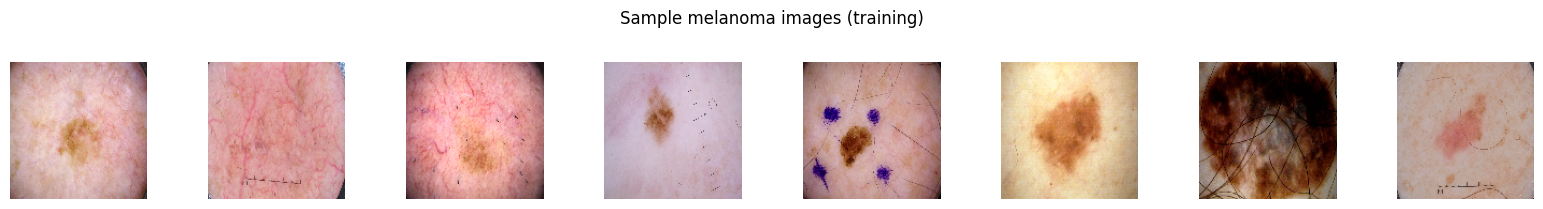

In [ ]:
# Quick sanity check — visualise a sample of melanoma training images
sample_batch, _ = next(iter(train_ds))
n = min(8, sample_batch.shape[0])

fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
for i in range(n):
    axes[i].imshow(sample_batch[i].numpy())
    axes[i].axis("off")
plt.suptitle("Sample melanoma images (training)", y=1.02)
plt.tight_layout()
plt.show()

## 3. Autoencoder Architecture

We build a symmetric **encoder–decoder** with skip-connection-style batch normalisation.

```
Input (128×128×3)
  │
  ▼  Encoder
 Conv 32  → BN → ReLU → MaxPool   →  64×64
 Conv 64  → BN → ReLU → MaxPool   →  32×32
 Conv 128 → BN → ReLU → MaxPool   →  16×16
 Conv 256 → BN → ReLU → MaxPool   →   8×8   [latent feature maps]
  │
  ▼  Decoder
 ConvTranspose 256 → BN → ReLU → UpSample → 16×16
 ConvTranspose 128 → BN → ReLU → UpSample → 32×32
 ConvTranspose  64 → BN → ReLU → UpSample → 64×64
 ConvTranspose  32 → BN → ReLU → UpSample → 128×128
 Conv 3 (sigmoid)                          → 128×128×3
```

In [ ]:
def conv_bn_relu(x, filters, kernel_size=3):
    """Conv2D + BatchNorm + ReLU block."""
    x = Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x


def deconv_bn_relu(x, filters, kernel_size=3):
    """Conv2DTranspose + BatchNorm + ReLU block."""
    x = Conv2DTranspose(filters, kernel_size, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x


def build_autoencoder(img_height, img_width, channels=3):
    """
    Returns (autoencoder, encoder, decoder) as separate Keras models
    so we can use each independently during generation.
    """
    # ── Encoder ───────────────────────────────────────────────────────────────
    encoder_input = Input(shape=(img_height, img_width, channels), name="encoder_input")

    x = conv_bn_relu(encoder_input, 32)
    x = MaxPooling2D((2, 2))(x)           # 64×64

    x = conv_bn_relu(x, 64)
    x = MaxPooling2D((2, 2))(x)           # 32×32

    x = conv_bn_relu(x, 128)
    x = MaxPooling2D((2, 2))(x)           # 16×16

    x = conv_bn_relu(x, 256)
    latent = MaxPooling2D((2, 2), name="latent")(x)  # 8×8×256

    encoder = Model(encoder_input, latent, name="encoder")

    # ── Decoder ───────────────────────────────────────────────────────────────
    decoder_input = Input(shape=encoder.output_shape[1:], name="decoder_input")

    x = deconv_bn_relu(decoder_input, 256)
    x = UpSampling2D((2, 2))(x)           # 16×16

    x = deconv_bn_relu(x, 128)
    x = UpSampling2D((2, 2))(x)           # 32×32

    x = deconv_bn_relu(x, 64)
    x = UpSampling2D((2, 2))(x)           # 64×64

    x = deconv_bn_relu(x, 32)
    x = UpSampling2D((2, 2))(x)           # 128×128

    decoder_output = Conv2D(channels, 3, padding="same", activation="sigmoid",
                            name="decoder_output")(x)  # 128×128×3

    decoder = Model(decoder_input, decoder_output, name="decoder")

    # ── Full autoencoder ──────────────────────────────────────────────────────
    autoencoder_output = decoder(encoder(encoder_input))
    autoencoder = Model(encoder_input, autoencoder_output, name="autoencoder")

    return autoencoder, encoder, decoder


autoencoder, encoder, decoder = build_autoencoder(IMG_HEIGHT, IMG_WIDTH)
autoencoder.summary(line_length=80)

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)        │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ encoder (Functional)              │ (None, 8, 8, 256)        │       389,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ decoder (Functional)              │ (None, 128, 128, 3)      │       979,683 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,369,539 (5.22 MB)

 Trainable params: 1,367,619 (5.22 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 4. Training

In [ ]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    # MSE + SSIM-based loss: MSE penalises pixel error, SSIM preserves structure
    loss="mse",
    metrics=["mae"]
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - loss: 0.0189 - mae: 0.0968 - val_loss: 0.0812 - val_mae: 0.2461 - learning_rate: 0.0010
Epoch 2/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0087 - mae: 0.0693 - val_loss: 0.0368 - val_mae: 0.1459 - learning_rate: 0.0010
Epoch 3/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0070 - mae: 0.0613 - val_loss: 0.0304 - val_mae: 0.1298 - learning_rate: 0.0010
Epoch 4/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0060 - mae: 0.0569 - val_loss: 0.0312 - val_mae: 0.1347 - learning_rate: 0.0010
Epoch 5/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0057 - mae: 0.0558 - val_loss: 0.0285 - val_mae: 0.1277 - learning_rate: 0.0010
Epoch 6/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0057 - mae: 0.0556 - val_loss: 0.0261 - val_mae: 0.1190 - learning_rate: 0.0010
Epoch 7/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0062 - mae: 0.0584 - val_loss: 0.0220 - val_mae: 0.1089 - learning_rate: 0.0010
Epoc

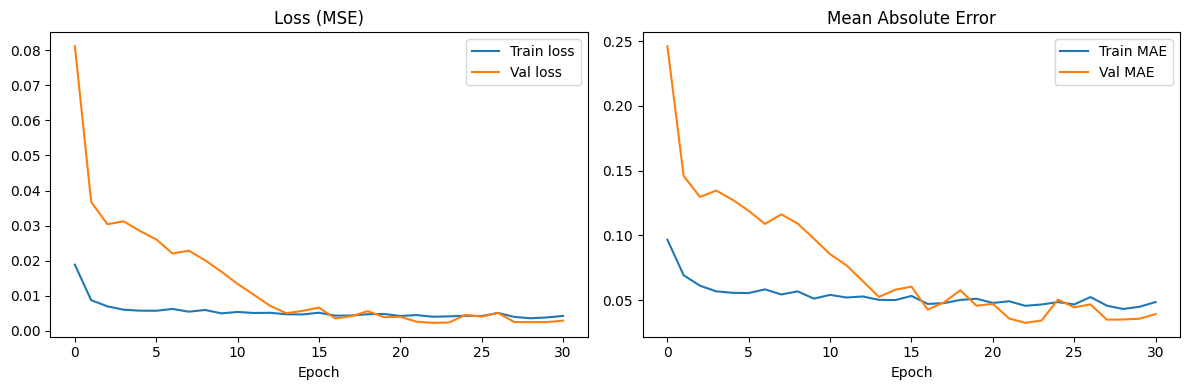

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["mae"],     label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("Mean Absolute Error")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Reconstruction Quality Check

Compare original melanoma images to their autoencoder reconstructions. Good reconstructions confirm the model has learned a useful latent representation of the minority class.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step


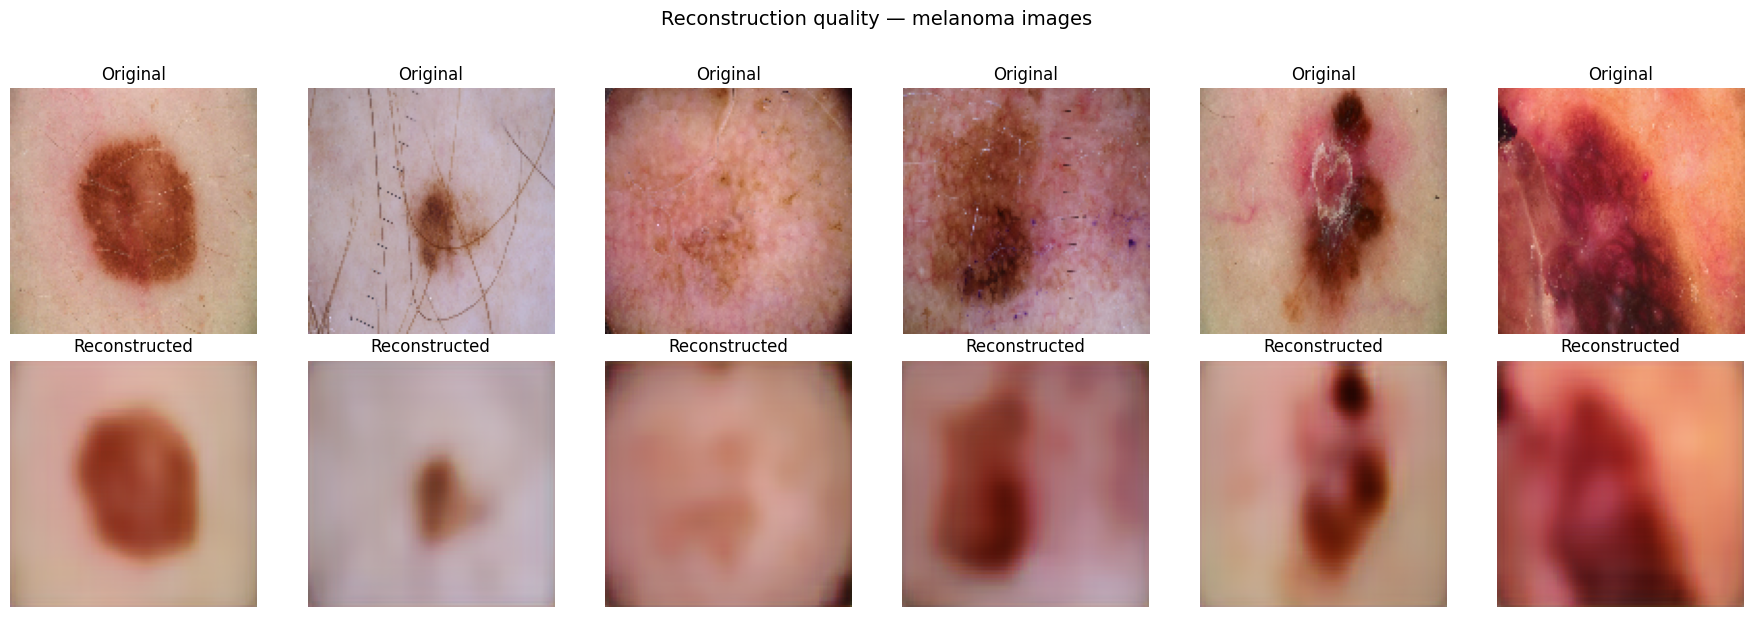

In [ ]:
# Take one validation batch
val_batch, _ = next(iter(val_ds))
reconstructions = autoencoder.predict(val_batch)

n = min(6, val_batch.shape[0])
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))

for i in range(n):
    axes[0, i].imshow(val_batch[i].numpy())
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(np.clip(reconstructions[i], 0, 1))
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.suptitle("Reconstruction quality — melanoma images", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 6. Synthetic Image Generation

**Strategy:** encode real melanoma images to get their latent vectors, add controlled Gaussian noise, then decode to produce new synthetic images. This keeps generated images close to the real distribution while introducing diversity.

In [ ]:
def encode_all_melanoma_images(encoder, filepaths, img_h, img_w, batch_size=16):
    """Encode all minority-class images and return a flat array of latent vectors."""
    latents = []
    for i in range(0, len(filepaths), batch_size):
        batch_paths = filepaths[i : i + batch_size]
        imgs = []
        for p in batch_paths:
            img = tf.io.read_file(p)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, [img_h, img_w])
            img = tf.cast(img, tf.float32) / 255.0
            imgs.append(img)
        batch_tensor = tf.stack(imgs)
        latent_batch = encoder.predict(batch_tensor, verbose=0)
        latents.append(latent_batch)
    return np.concatenate(latents, axis=0)


print("Encoding all real melanoma images into latent space …")
all_latents = encode_all_melanoma_images(
    encoder, melanoma_files["filepath"].values,
    IMG_HEIGHT, IMG_WIDTH
)
print(f"Latent array shape: {all_latents.shape}")
print(f"  → {all_latents.shape[0]} images × {all_latents.shape[1]}×{all_latents.shape[2]}×{all_latents.shape[3]} feature maps")

Encoding all real melanoma images into latent space …
Latent array shape: (500, 8, 8, 256)
  → 500 images × 8×8×256 feature maps


In [ ]:
def generate_synthetic_images(decoder, latents, n_images, noise_std, output_dir,
                               img_h, img_w, batch_size=32):
    """
    Generate `n_images` synthetic images by:
      1. Randomly sampling a real latent vector.
      2. Adding Gaussian noise scaled by `noise_std` × latent std.
      3. Decoding and saving as JPEG.

    Returns list of saved file paths.
    """
    rng       = np.random.default_rng(SEED)
    saved     = []
    n_real    = len(latents)
    latent_std = latents.std()   # global std for noise scaling

    for start in range(0, n_images, batch_size):
        end   = min(start + batch_size, n_images)
        count = end - start

        # Sample real latents with replacement and perturb them
        idxs    = rng.integers(0, n_real, size=count)
        sampled = latents[idxs].copy()
        noise   = rng.normal(0, noise_std * latent_std, size=sampled.shape)
        perturbed = sampled + noise

        # Decode batch
        decoded = decoder.predict(perturbed.astype(np.float32), verbose=0)
        decoded = np.clip(decoded, 0.0, 1.0)

        for j in range(count):
            img_array = (decoded[j] * 255).astype(np.uint8)
            img_tensor = tf.constant(img_array)
            encoded_jpg = tf.image.encode_jpeg(img_tensor, quality=95)

            fname = f"synthetic_melanoma_{start + j:05d}.jpg"
            fpath = os.path.join(output_dir, fname)
            tf.io.write_file(fpath, encoded_jpg)
            saved.append(fpath)

        print(f"  Generated {end}/{n_images} images …", end="\r")

    print(f"\nDone — {len(saved)} images saved to: {output_dir}")
    return saved


print(f"Generating {NUM_SYNTHETIC_IMAGES} synthetic melanoma images …")
synthetic_paths = generate_synthetic_images(
    decoder      = decoder,
    latents      = all_latents,
    n_images     = NUM_SYNTHETIC_IMAGES,
    noise_std    = NOISE_STD,
    output_dir   = GEN_OUTPUT_DIR,
    img_h        = IMG_HEIGHT,
    img_w        = IMG_WIDTH,
)

Generating 2000 synthetic melanoma images …
  Generated 2000/2000 images …
Done — 2000 images saved to: /content/drive/MyDrive/Vision AI/Final Project Sample Data/generated_melanoma


## 7. Verify Generated Images

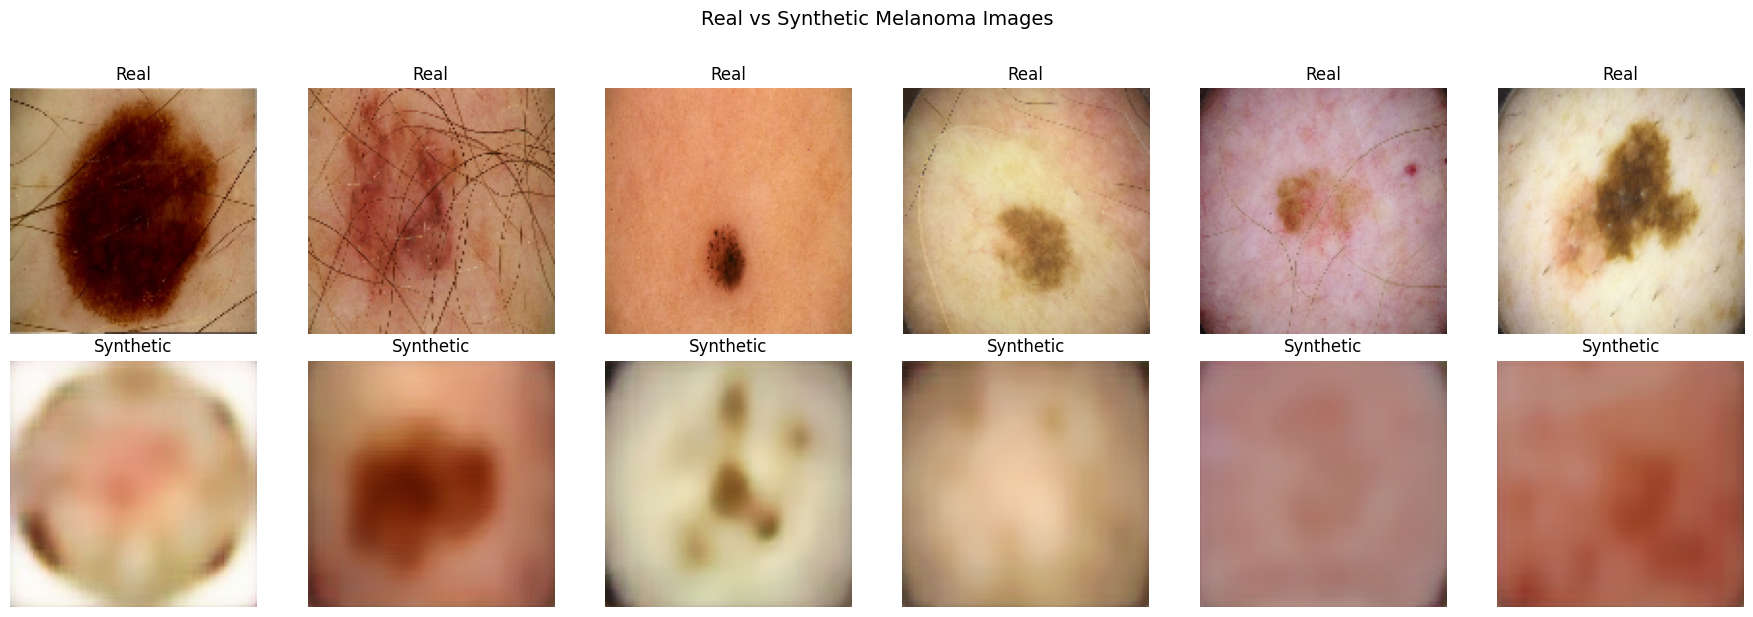

In [ ]:
# Visual comparison: real vs synthetic
n_show = 6
real_sample_paths    = melanoma_files["filepath"].values[:n_show]
synth_sample_paths   = synthetic_paths[:n_show]

def read_img(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    return (img.numpy() / 255.0)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))

for i in range(n_show):
    axes[0, i].imshow(read_img(real_sample_paths[i]))
    axes[0, i].set_title("Real")
    axes[0, i].axis("off")

    axes[1, i].imshow(read_img(synth_sample_paths[i]))
    axes[1, i].set_title("Synthetic")
    axes[1, i].axis("off")

plt.suptitle("Real vs Synthetic Melanoma Images", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

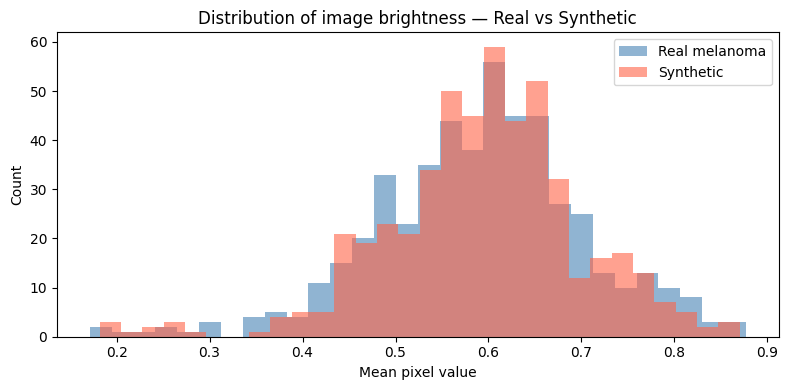

Real    mean brightness: 0.5909 ± 0.1127
Synth   mean brightness: 0.5935 ± 0.1061


In [ ]:
# Pixel-space diversity check — plot distribution of mean pixel values
real_means  = [read_img(p).mean() for p in melanoma_files["filepath"].values]
synth_means = [read_img(p).mean() for p in synthetic_paths[:len(real_means)]]

plt.figure(figsize=(8, 4))
plt.hist(real_means,  bins=30, alpha=0.6, label="Real melanoma",  color="steelblue")
plt.hist(synth_means, bins=30, alpha=0.6, label="Synthetic",       color="tomato")
plt.xlabel("Mean pixel value")
plt.ylabel("Count")
plt.title("Distribution of image brightness — Real vs Synthetic")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Real    mean brightness: {np.mean(real_means):.4f} ± {np.std(real_means):.4f}")
print(f"Synth   mean brightness: {np.mean(synth_means):.4f} ± {np.std(synth_means):.4f}")

In [ ]:
# Effect on class balance if synthetic images are added to the training set
n_real_train_melanoma = len(melanoma_files)
n_synthetic           = len(synthetic_paths)

# Retrieve benign count from original train split
# (adjust if you have the exact count)
benign_count_estimate = int(n_real_train_melanoma / 0.012)  # ~1.2 % melanoma
new_melanoma_total    = n_real_train_melanoma + n_synthetic
new_ratio             = benign_count_estimate / new_melanoma_total

print("Class balance summary")
print("-" * 40)
print(f"Real benign (est.)     : {benign_count_estimate:>7,}")
print(f"Real melanoma          : {n_real_train_melanoma:>7,}")
print(f"Synthetic melanoma     : {n_synthetic:>7,}")
print(f"Total melanoma         : {new_melanoma_total:>7,}")
print(f"New imbalance ratio    : {new_ratio:.1f}:1  (was ~98:1)")

Class balance summary
----------------------------------------
Real benign (est.)     :  41,666
Real melanoma          :     500
Synthetic melanoma     :   2,000
Total melanoma         :   2,500
New imbalance ratio    : 16.7:1  (was ~98:1)


## 8. Save Models

In [ ]:
autoencoder.save(f"{MODEL_SAVE_DIR}/melanoma_autoencoder.keras")
encoder.save(f"{MODEL_SAVE_DIR}/melanoma_encoder.keras")
decoder.save(f"{MODEL_SAVE_DIR}/melanoma_decoder.keras")
print("Models saved.")

Models saved.
